In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("C:\\Brototype\\ML_learn\\ML_projects\\Data_Preparation\\DATASETS\\Titanic-Dataset.csv")

In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [47]:
df.isnull().sum().sum()

np.int64(0)

In [20]:
df['Age']= df['Age'].fillna(df['Age'].mean())

In [40]:
df['Has_Cabin']=(df['Cabin'].notnull()).astype(int)
df['Has_Cabin']
df=df.drop('Cabin', axis=1)

In [45]:
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])

In [7]:
survived_df=df[df["Survived"] == 1]
print(survived_df["Survived"].count())

342


In [8]:
Male=df[(df["Sex"]== "male") & (df["Survived"] == 1)]

print(Male["Sex"])

17     male
21     male
23     male
36     male
55     male
       ... 
838    male
839    male
857    male
869    male
889    male
Name: Sex, Length: 109, dtype: object


In [9]:
Female=df[(df["Sex"]== "female")  & (df["Survived"] == 1)]

print(Female["Sex"])

1      female
2      female
3      female
8      female
9      female
        ...  
874    female
875    female
879    female
880    female
887    female
Name: Sex, Length: 233, dtype: object


In [10]:
df.groupby('Sex')["Survived"].mean().round(3)

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

In [11]:
print(df['Fare'].max())

512.3292


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
print(df[df['Fare'] == 0]['Name'].count())

15


In [14]:
q1 = df['Fare'].quantile(0.25)
q3 = df['Fare'].quantile(0.75)
iqr=q3-q1
lower_bound= q1-1.5*iqr
outer_bound = q3+1.5*iqr
print(lower_bound, outer_bound)

-26.724 65.6344


In [15]:

filtered_fare = df[(df['Fare']<= lower_bound) | (df['Fare']>= outer_bound)]
df['Fare']


0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

In [16]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [17]:
df["Age"].std()


np.float64(14.526497332334042)

In [18]:
df["Embarked"].mode()[0]

'S'

AttributeError: module 'matplotlib.pyplot' has no attribute 'x_label'

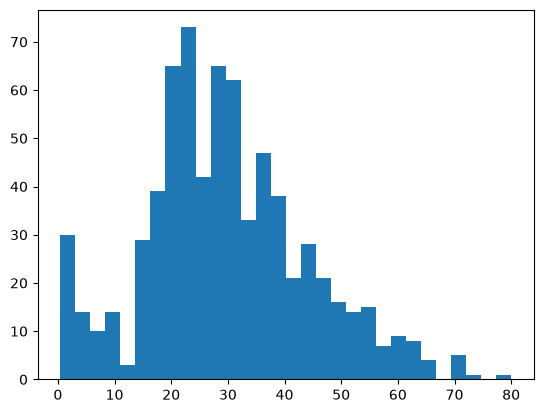

In [19]:
import matplotlib.pyplot as plt
plt.hist(df['Age'], bins=30)
plt.x_label()

In [ ]:
df.groupby('Pclass')['Pclass'].count()

Pclass
1    216
2    184
3    491
Name: Pclass, dtype: int64

In [ ]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [ ]:
q1=df['SibSp'].quantile(0.25)
q3=df['SibSp'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
outer_bound = q3+ 1.5*iqr
filtered_SibSp= df[(df['SibSp']>=outer_bound)| (df['SibSp']<=lower_bound)]
print(filtered_SibSp)

     PassengerId  Survived  Pclass  \
7              8         0       3   
16            17         0       3   
24            25         0       3   
27            28         0       1   
50            51         0       3   
59            60         0       3   
63            64         0       3   
68            69         1       3   
71            72         0       3   
85            86         1       3   
88            89         1       1   
119          120         0       3   
159          160         0       3   
164          165         0       3   
171          172         0       3   
176          177         0       3   
180          181         0       3   
182          183         0       3   
201          202         0       3   
229          230         0       3   
233          234         1       3   
261          262         1       3   
266          267         0       3   
278          279         0       3   
324          325         0       3   
341         

In [ ]:
df['Survived'].corr(df['Pclass'])

np.float64(-0.3384810359610148)

In [ ]:
df['Fare'].corr(df['Age'])

np.float64(0.09606669176903894)

In [ ]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [ ]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

In [ ]:
df.corr(numeric_only=True).round(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000,-0.005,-0.035,0.037,-0.058,-0.002,0.013
Survived,-0.005,1.000,-0.338,-0.077,-0.035,0.082,0.257
Pclass,-0.035,-0.338,1.000,-0.369,0.083,0.018,-0.549
Age,0.037,-0.077,-0.369,1.000,-0.308,-0.189,0.096
SibSp,-0.058,-0.035,0.083,-0.308,1.000,0.415,0.160
Parch,-0.002,0.082,0.018,-0.189,0.415,1.000,0.216
Fare,0.013,0.257,-0.549,0.096,0.160,0.216,1.000


In [ ]:
import matplotlib.pyplot as plt

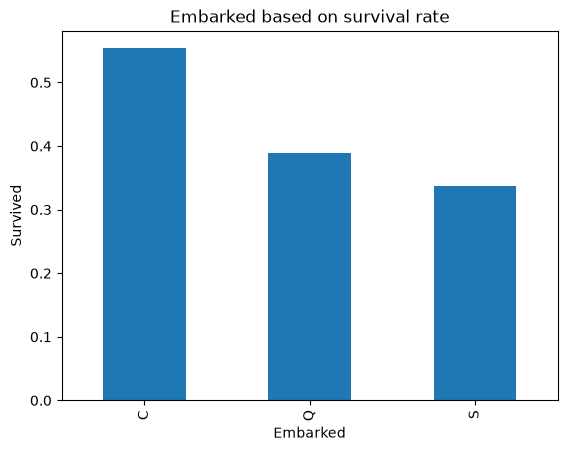

In [ ]:
emb_survive = df.groupby("Embarked")['Survived'].mean()
emb_survive.plot(kind='bar', title='Embarked based on survival rate', xlabel='Embarked', ylabel='Survived')
plt.show()

In [ ]:
df['Survived'].value_counts(normalize=True)

NameError: name 'df' is not defined